In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# data visualization library
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
data = pd.read_csv("Covid Dataset.csv")

In [ ]:
data

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5429,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,No,...,Yes,Yes,No,No,No,No,No,No,No,Yes
5430,Yes,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,...,Yes,No,No,No,No,No,No,No,No,Yes
5431,Yes,Yes,Yes,No,No,No,No,No,Yes,No,...,No,No,No,No,No,No,No,No,No,No
5432,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,No,...,No,No,No,No,No,No,No,No,No,No


In [ ]:
data.describe(include = 'all')

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
count,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434,...,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,1,1,2
top,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,No,...,Yes,No,No,Yes,No,Yes,No,No,No,Yes
freq,3620,4273,4307,3953,2952,2920,2869,2736,2911,2846,...,2821,2883,2983,2726,2924,2820,3172,5434,5434,4383


In [ ]:
data=data.drop('Sanitization from Market',axis=1)
data=data.drop('Wearing Masks',axis=1)

In [ ]:
# create a table with data missing
missing_values=data.isnull().sum() # missing values

frame = pd.DataFrame(missing_values)
frame

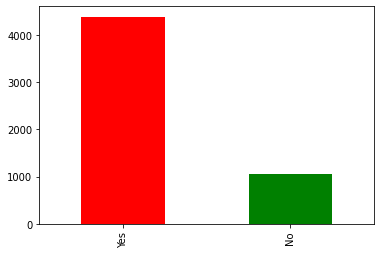

In [ ]:
data["COVID-19"].value_counts().plot(kind="bar", color=["red", "green"]);

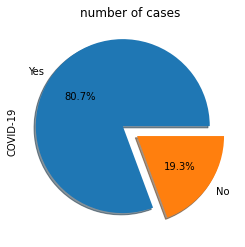

In [ ]:
data["COVID-19"].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True)
plt.title('number of cases');

In [ ]:
features = data.columns.tolist()
features.remove('COVID-19')
print(features)

['Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat', 'Running Nose', 'Asthma', 'Chronic Lung Disease', 'Headache', 'Heart Disease', 'Diabetes', 'Hyper Tension', 'Fatigue ', 'Gastrointestinal ', 'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering', 'Visited Public Exposed Places', 'Family working in Public Exposed Places']


In [ ]:
for feature in features:
    plt.figure()
    sns.countplot(x= feature,hue='COVID-19',data=data)

In [ ]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()

In [ ]:
data=data.apply(l.fit_transform).astype(int)

In [ ]:
data

In [ ]:
correlation = data.corr()
correlation.style.background_gradient(cmap='coolwarm',axis=None)

In [ ]:
# Splitting Dependent and Independent features
X = data.drop('COVID-19',axis=1)
y = data['COVID-19']


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, random_state=0)

KNN algorithm

Minimum error:- 0.016188373804267846 at K = 2


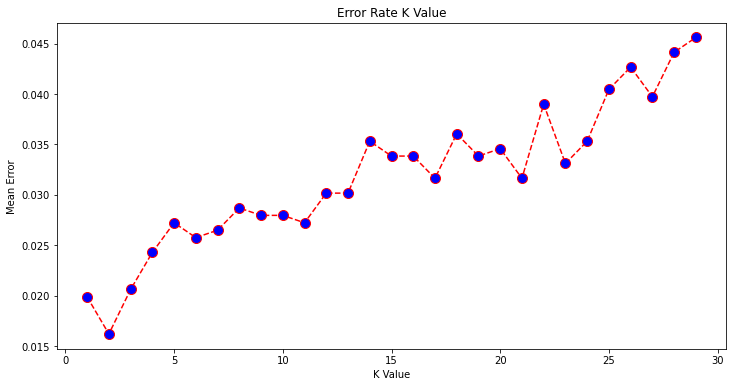

In [ ]:
error = []
# Calculating error for K values between 1 and 30
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 30), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
print("Minimum error:-",min(error),"at K =",error.index(min(error))+1)

In [ ]:
knnclassifier= KNeighborsClassifier(n_neighbors=2)
knnclassifier.fit(X_train, y_train)
y_pred= knnclassifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

print("Training score: ",accuracy_score(knnclassifier.predict(X_train), y_train))

[[ 259    2]
 [  20 1078]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       261
           1       1.00      0.98      0.99      1098

    accuracy                           0.98      1359
   macro avg       0.96      0.99      0.97      1359
weighted avg       0.98      0.98      0.98      1359

0.9838116261957321
Training score:  0.9811042944785276


In [ ]:
import xgboost

In [ ]:
xgb = xgboost.XGBClassifier(use_label_encoder=False)
xgb.fit(X_train, y_train, eval_metric='error')

XGBClassifier(use_label_encoder=False)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))
print(accuracy_score(y_test,y_pred_xgb))

print("Training score: ",accuracy_score(xgb.predict(X_train), y_train))

[[ 227   34]
 [   7 1091]]
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       261
           1       0.97      0.99      0.98      1098

    accuracy                           0.97      1359
   macro avg       0.97      0.93      0.95      1359
weighted avg       0.97      0.97      0.97      1359

0.9698307579102281
Training score:  0.9771779141104294


In [ ]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
y_test_pred = dt.predict(X_test)
print(confusion_matrix(y_test,y_test_pred))
print(classification_report(y_test,y_test_pred))
print(accuracy_score(y_test,y_test_pred))

print("Training score: ",accuracy_score(dt.predict(X_train), y_train))

[[ 206   55]
 [   1 1097]]
              precision    recall  f1-score   support

           0       1.00      0.79      0.88       261
           1       0.95      1.00      0.98      1098

    accuracy                           0.96      1359
   macro avg       0.97      0.89      0.93      1359
weighted avg       0.96      0.96      0.96      1359

0.9587932303164092
Training score:  0.9651533742331289


In [ ]:
from sklearn.ensemble import RandomForestClassifier
Rfclassifier = RandomForestClassifier(n_estimators =5, random_state = 0)
Rfclassifier.fit(X_train,y_train)
Y_Pred = Rfclassifier.predict(X_test)

print(confusion_matrix(y_test,Y_Pred))
print(classification_report(y_test,Y_Pred))
print(accuracy_score(y_test,Y_Pred))

print("Training score: ",accuracy_score(Rfclassifier.predict(X_train), y_train))

[[ 249   12]
 [  15 1083]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       261
           1       0.99      0.99      0.99      1098

    accuracy                           0.98      1359
   macro avg       0.97      0.97      0.97      1359
weighted avg       0.98      0.98      0.98      1359

0.9801324503311258
Training score:  0.983558282208589
